In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

seeds = [42,0,1]

syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]

In [94]:
#### Uivariate
##42

univariate_clinical_42 = [0.973, 0.970, 0.944, 0.973, 0.968, 0.646]
##0
univariate_clinical_0 = [0.977, 0.972, 0.941, 0.963, 0.968, 0.615]

## 1
univariate_clinical_1 = [0.977, 0.967, 0.937, 0.966, 0.972, 0.660]

##42
univariate_transcriptomics_42 = [0.803, 0.766, 0.726, 0.815, 0.936, 0.616]

##0
univariate_transcriptomics_0 = [0.804, 0.769, 0.671, 0.814, 0.939, 0.627]

##1
univariate_transcriptomics_1 = [0.804, 0.767, 0.706, 0.816, 0.932, 0.668]



univariate_similarity_42 = ( np.array(univariate_clinical_42) +  np.array(univariate_transcriptomics_42)) / 2
univariate_similarity_42 = univariate_similarity_42.tolist()

univariate_similarity_0 = ( np.array(univariate_clinical_0) +  np.array(univariate_transcriptomics_0)) / 2
univariate_similarity_0 = univariate_similarity_0.tolist()

univariate_similarity_1 = ( np.array(univariate_clinical_1) +  np.array(univariate_transcriptomics_1)) / 2
univariate_similarity_1 = univariate_similarity_1.tolist()

Univariate_Similarity = {}
Univariate_Similarity[seeds[0]] = univariate_similarity_42
Univariate_Similarity[seeds[1]] = univariate_similarity_0
Univariate_Similarity[seeds[2]] = univariate_similarity_1

In [95]:
##### Pairwise

##42
pw_clinical_42 = [0.978, 0.976, 0.835, 0.953, 0.906, 0.806]

##0
pw_clinical_0 = [0.978, 0.973, 0.835, 0.955, 0.909, 0.798]

## 1
pw_clinical_1 = [0.976, 0.976, 0.835, 0.945, 0.907, 0.825]

##42
pw_transcriptomics_42 = [0.956, 0.955, 0.925, 0.957, 0.945, 0.931]

##0
pw_transcriptomics_0 = [0.956, 0.955, 0.926, 0.958, 0.950, 0.931]

##1
pw_transcriptomics_1 = [0.956, 0.955, 0.925, 0.957, 0.949, 0.931]



pw_similarity_42 = (np.array(pw_clinical_42) + np.array(pw_clinical_42)) / 2
pw_similarity_42 = pw_similarity_42.tolist()

pw_similarity_0 = (np.array(pw_clinical_0) + np.array(pw_clinical_0)) / 2
pw_similarity_0 = pw_similarity_0.tolist()

pw_similarity_1 = (np.array(pw_clinical_1) + np.array(pw_clinical_1)) / 2
pw_similarity_1 = pw_similarity_1.tolist()



Pw_Similarity = {}
Pw_Similarity[seeds[0]] = pw_similarity_42
Pw_Similarity[seeds[1]] = pw_similarity_0
Pw_Similarity[seeds[2]] = pw_similarity_1

In [96]:
## ssGSEA
ssGSEA_Scores = {}
for seed in seeds:
    jaccardindexesDF = pd.read_csv(f"ssGSEA/JaccardIndex_{seed}.csv")
    jaccardindexes = jaccardindexesDF["Jaccard"].values.tolist()
    
    ssGSEA_spearmanDF = pd.read_csv(f"ssGSEA/Spearman_df{seed}.csv")
    ssGSEA_spearman = np.absolute(ssGSEA_spearmanDF["Spearman_rho"].values.tolist())
    
    ssGSEA_scores = (np.array(jaccardindexes) + np.array(ssGSEA_spearman)) / 2
    ssGSEA_scores = ssGSEA_scores.tolist()
    ssGSEA_Scores[seed] = ssGSEA_scores

In [97]:
##ImmuneDeco
ImmuneDecos_Scores = {}
for seed in seeds:
    jaccardindexesDF = pd.read_csv(f"ImmuneDecovo/JaccardIndex_{seed}.csv")
    jaccardindexes = jaccardindexesDF["Jaccard"].values.tolist()
    
    ImmuneDeco_spearmanDF = pd.read_csv(f"ImmuneDecovo/Spearman_{seed}.csv")
    ImmuneDeco_spearman = np.absolute(ImmuneDeco_spearmanDF["Spearman_rho"].values.tolist())
    
    if len(jaccardindexes) != len(ImmuneDeco_spearman):
        jaccardindexes.append(np.nan)
        
    ImmuneDecos_scores = (np.array(jaccardindexes) + np.array(ImmuneDeco_spearman)) / 2
    ImmuneDecos_scores = ImmuneDecos_scores.tolist()
    ImmuneDecos_Scores[seed]=ImmuneDecos_scores 

In [99]:
## DEGS
DEG_Scores = {}
for seed in seeds:
    jaccardindexesDF = pd.read_csv(f"DEG/JaccardIndex_{seed}.csv")
    jaccardindexes = jaccardindexesDF["Jaccard"].values.tolist()
    
    DEG_spearmanDF = pd.read_csv(f"DEG/Spearman_df{seed}.csv")
    DEG_spearman = np.absolute(DEG_spearmanDF["Spearman_rho"].values.tolist())
    
    if len(jaccardindexes) != len(ImmuneDeco_spearman):
        jaccardindexes.append(np.nan)
        
    DEG_scores = (np.array(jaccardindexes) + np.array(DEG_spearman)) / 2
    DEG_scores = DEG_scores.tolist()
    DEG_Scores[seed] = DEG_scores

In [100]:
###SurvivalAnalysis
SA_Scores = {}
for seed in seeds:
    dfSA = pd.read_csv(f"SurvivalAnalysis/Survival_Responder_{seed}.csv")
    SA_scores = dfSA["Average"].values.tolist()[1:]
    SA_Scores[seed] = SA_scores

In [102]:
#SinglingOut
SinglingOut_Scores = {}
Linkability_Scores = {}
Inference_Scores = {}
for seed in seeds:
    syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
    SO_df = pd.read_csv(f"Privacy/SinglingOut_Results_{seed}.csv")
    df_SOpivot = pd.pivot_table(
        SO_df,
        values='attack_rate',  
        index='Case', 
        columns='Dataset', 
    )
    SinglingOut_scores = []
    statistic_df = df_SOpivot.describe()
    for dataset in syn_datas:
        risk =statistic_df.loc["mean",dataset]
        score = 1 - risk
        SinglingOut_scores.append(score)
    SinglingOut_Scores[seed] = SinglingOut_scores
    
    #Linkability
    Link_df = pd.read_csv(f"Linkability/LinkabilityResults_{seed}.csv")
    Link_scores = []
    for dataset in syn_datas:
        risk =np.mean(Link_df.loc[:,dataset])
        score = 1-risk
        Link_scores.append(score)
    Linkability_Scores[seed] = Link_scores
    
    #Inference
    Infereces_df = pd.read_csv(f"Inferences/df_InferencesRisk_{seed}.csv")
    dfpivot_Inferece = pd.pivot_table(
        Infereces_df,
        values='attack_rate',  
        index='Atribute', 
        columns='Dataset', 
    )
    
    Inference_scores = []
    inferences_statistic_df = dfpivot_Inferece.describe()
    for dataset in syn_datas:
        risk =inferences_statistic_df.loc["mean",dataset]
        score = 1 - risk
        Inference_scores.append(score)
    Inference_Scores[seed]= Inference_scores

In [107]:
import matplotlib.lines as mlines

data_seed = {}
tools = ["avatarsk5","avatarsk10","ctgan","gaussiancopula","synthpop","tvae"]
for seed in seeds:
    data = {
    "Dataset": tools,
    "Univariate Similarity": Univariate_Similarity[seed],
    "Pairwise Similarity": Pw_Similarity[seed],
    "ssGSEA": ssGSEA_Scores[seed],
    "Survival Analysis": SA_Scores[seed],
    "Immune Cell Decovolution": ImmuneDecos_Scores[seed],
    "DEGs": DEG_Scores[seed],
    "SinglingOut Score" : SinglingOut_Scores[seed],
    "Linkability Score": Linkability_Scores[seed],
    "Inference Score": Inference_Scores[seed]   
}
    
    data_seed[seed] = data

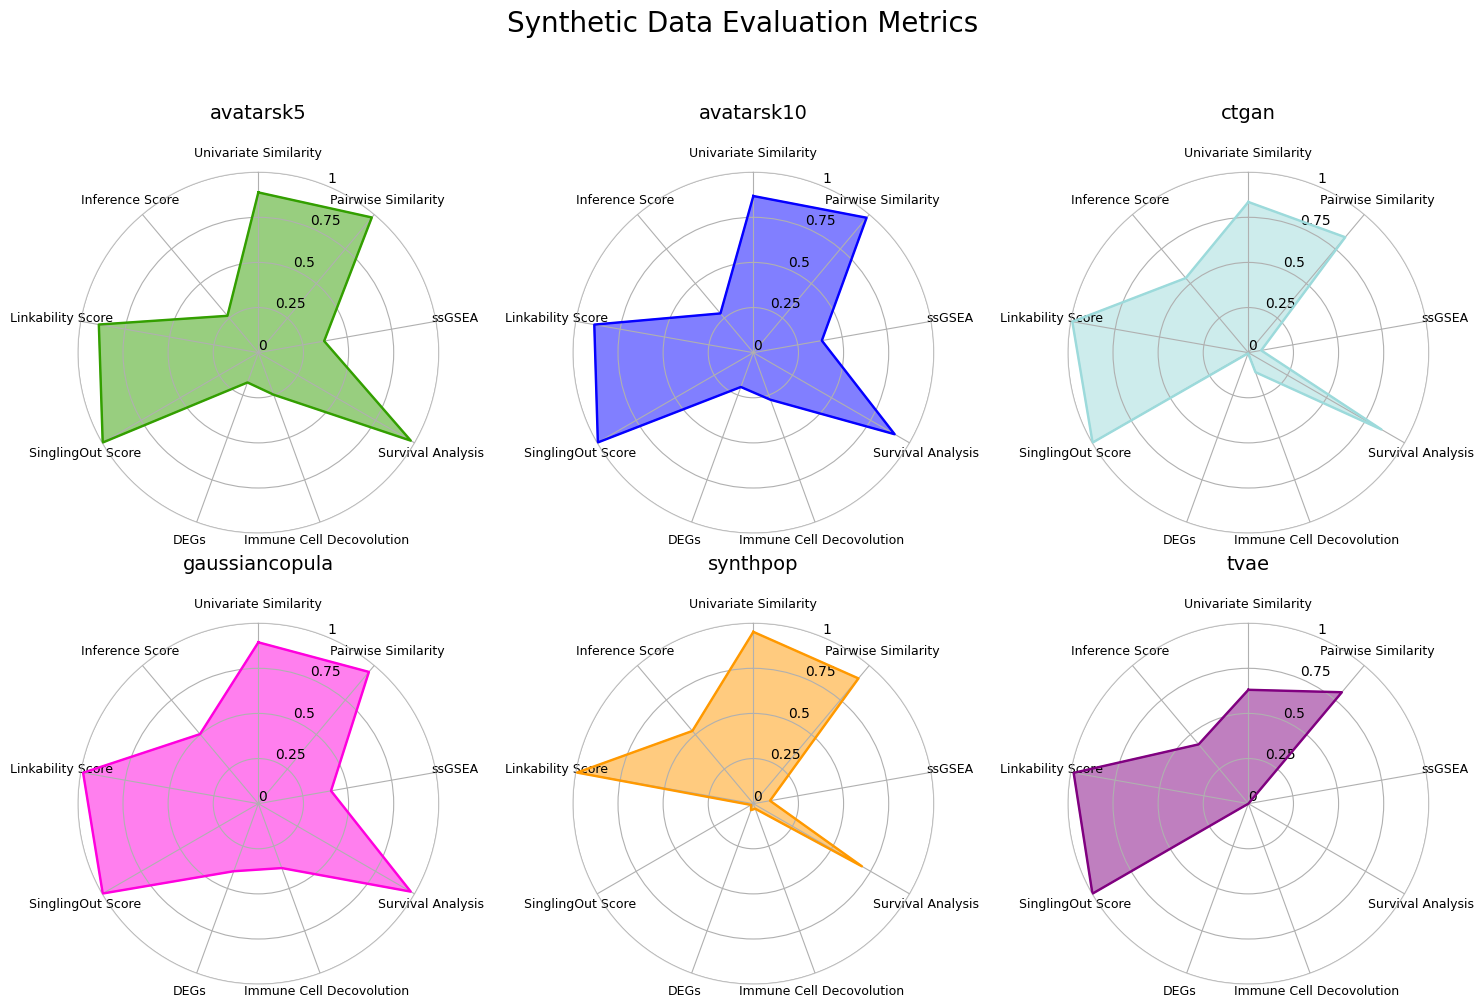

In [108]:

seed = 42
df = pd.DataFrame(data_seed[seed])
df = df.fillna(0)
metrics = df.columns[1:].tolist()

# --- 2. Plot Setup Parameters ---
N = len(metrics)
# Calculate angles for each metric (theta)
theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
# Close the circle by adding the start angle to the end
theta = np.concatenate([theta, [theta[0]]])

# Ticks for the 0-1 radial axis
r_ticks = [0, 0.25, 0.5, 0.75, 1.0]
r_labels = ["0", "0.25", "0.5", "0.75", "1"]

# Color palette with 6 distinct colors for the 6 datasets
color_palette = ['#339F00', '#0500FF', '#9CDADB', '#FF00DE', '#FF9900', '#800080']

# --- 3. Subplot Initialization ---
# Initialize figure and 6 polar subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw={"projection": "polar"})
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

# --- 4. Plotting Loop ---
for idx, (i, row) in enumerate(df.iterrows()):
    ax = axes[idx]
    
    # Data for the current dataset (kept in 0-1 range)
    values = row[metrics].values.flatten().tolist()
    values = values + [values[0]]
    plot_color = color_palette[idx]
    dataset_name = row['Dataset']
    
    # Plotting line and fill
    ax.plot(theta, values, linewidth=1.75, linestyle="solid", color=plot_color)
    ax.fill(theta, values, alpha=0.50, color=plot_color)
    
    # Subplot visual settings
    ax.set_title(dataset_name, size=14, pad=20) # Dataset name as title
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.spines["polar"].set_zorder(1)
    ax.spines["polar"].set_color('lightgrey')
    
    # Ticks and limits
    ax.set_ylim(0, 1.0)
    ax.set_yticks(r_ticks)
    ax.set_yticklabels(r_labels, color="black", size=10)

    # Metric labels (set once per subplot)
    ax.set_xticks(theta[:-1])
    ax.set_xticklabels(metrics, color='black', size=9) 

# --- 5. Final Figure Settings ---
# Set a title for the entire figure
fig.suptitle("Synthetic Data Evaluation Metrics", fontsize=20, y=1.0)
# Adjust layout to prevent overlap
fig.tight_layout(rect=[0, 0, 1, 0.96]) 
# fig.savefig(f"SummaryRadarPlot_{seed}.png", dpi = 300, bbox_inches="tight")
plt.show()

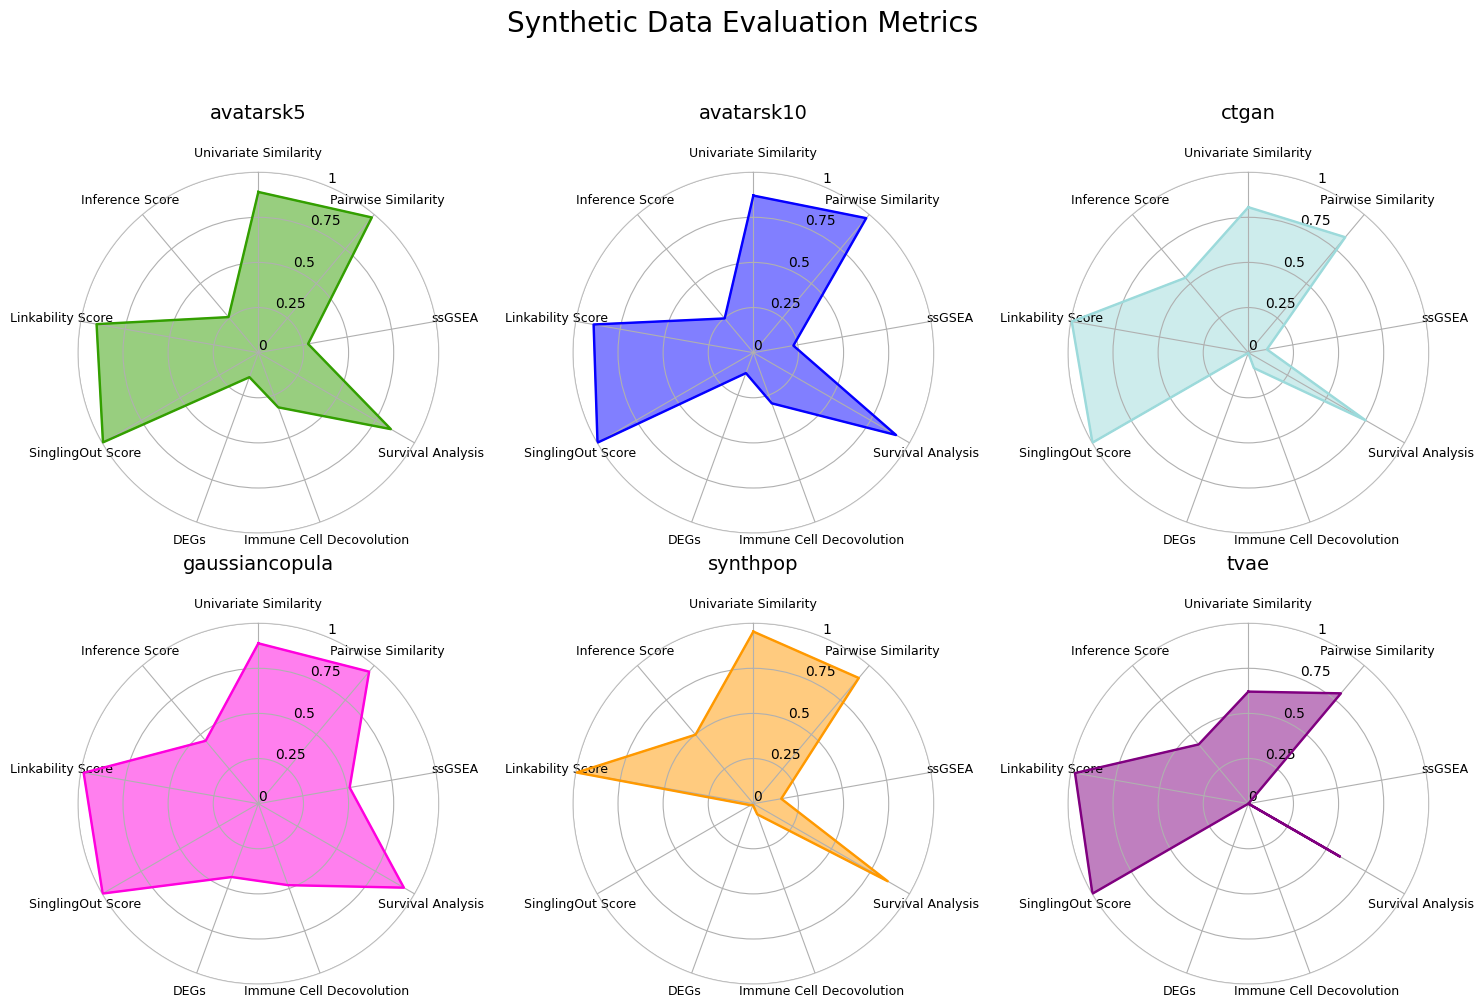

In [115]:
seed = 0
df = pd.DataFrame(data_seed[seed])
df = df.fillna(0)
metrics = df.columns[1:].tolist()

# --- 2. Plot Setup Parameters ---
N = len(metrics)
# Calculate angles for each metric (theta)
theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
# Close the circle by adding the start angle to the end
theta = np.concatenate([theta, [theta[0]]])

# Ticks for the 0-1 radial axis
r_ticks = [0, 0.25, 0.5, 0.75, 1.0]
r_labels = ["0", "0.25", "0.5", "0.75", "1"]

# Color palette with 6 distinct colors for the 6 datasets
color_palette = ['#339F00', '#0500FF', '#9CDADB', '#FF00DE', '#FF9900', '#800080']

# --- 3. Subplot Initialization ---
# Initialize figure and 6 polar subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw={"projection": "polar"})
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

# --- 4. Plotting Loop ---
for idx, (i, row) in enumerate(df.iterrows()):
    ax = axes[idx]
    
    # Data for the current dataset (kept in 0-1 range)
    values = row[metrics].values.flatten().tolist()
    values = values + [values[0]]
    plot_color = color_palette[idx]
    dataset_name = row['Dataset']
    
    # Plotting line and fill
    ax.plot(theta, values, linewidth=1.75, linestyle="solid", color=plot_color)
    ax.fill(theta, values, alpha=0.50, color=plot_color)
    
    # Subplot visual settings
    ax.set_title(dataset_name, size=14, pad=20) # Dataset name as title
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.spines["polar"].set_zorder(1)
    ax.spines["polar"].set_color('lightgrey')
    
    # Ticks and limits
    ax.set_ylim(0, 1.0)
    ax.set_yticks(r_ticks)
    ax.set_yticklabels(r_labels, color="black", size=10)

    # Metric labels (set once per subplot)
    ax.set_xticks(theta[:-1])
    ax.set_xticklabels(metrics, color='black', size=9) 

# --- 5. Final Figure Settings ---
# Set a title for the entire figure
fig.suptitle("Synthetic Data Evaluation Metrics", fontsize=20, y=1.0)
# Adjust layout to prevent overlap
fig.tight_layout(rect=[0, 0, 1, 0.96]) 
fig.savefig(f"SummaryRadarPlot_{seed}.png", dpi = 300, bbox_inches="tight")
plt.show()

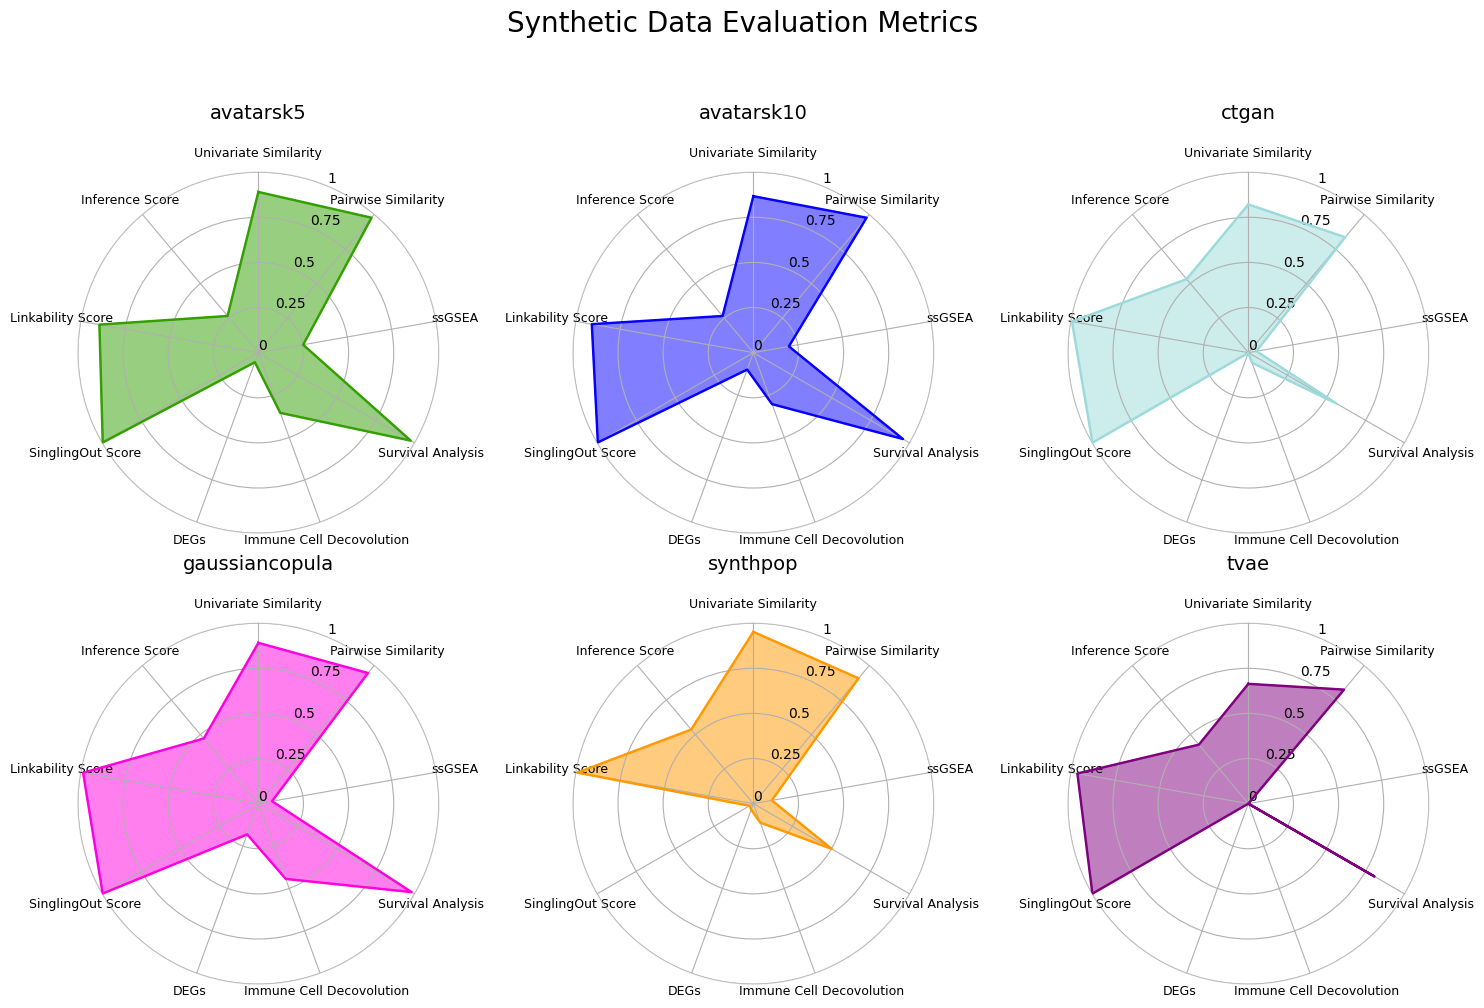

In [116]:
seed = 1
df = pd.DataFrame(data_seed[seed])
df = df.fillna(0)
metrics = df.columns[1:].tolist()

# --- 2. Plot Setup Parameters ---
N = len(metrics)
# Calculate angles for each metric (theta)
theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
# Close the circle by adding the start angle to the end
theta = np.concatenate([theta, [theta[0]]])

# Ticks for the 0-1 radial axis
r_ticks = [0, 0.25, 0.5, 0.75, 1.0]
r_labels = ["0", "0.25", "0.5", "0.75", "1"]

# Color palette with 6 distinct colors for the 6 datasets
color_palette = ['#339F00', '#0500FF', '#9CDADB', '#FF00DE', '#FF9900', '#800080']

# --- 3. Subplot Initialization ---
# Initialize figure and 6 polar subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw={"projection": "polar"})
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

# --- 4. Plotting Loop ---
for idx, (i, row) in enumerate(df.iterrows()):
    ax = axes[idx]
    
    # Data for the current dataset (kept in 0-1 range)
    values = row[metrics].values.flatten().tolist()
    values = values + [values[0]]
    plot_color = color_palette[idx]
    dataset_name = row['Dataset']
    
    # Plotting line and fill
    ax.plot(theta, values, linewidth=1.75, linestyle="solid", color=plot_color)
    ax.fill(theta, values, alpha=0.50, color=plot_color)
    
    # Subplot visual settings
    ax.set_title(dataset_name, size=14, pad=20) # Dataset name as title
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.spines["polar"].set_zorder(1)
    ax.spines["polar"].set_color('lightgrey')
    
    # Ticks and limits
    ax.set_ylim(0, 1.0)
    ax.set_yticks(r_ticks)
    ax.set_yticklabels(r_labels, color="black", size=10)

    # Metric labels (set once per subplot)
    ax.set_xticks(theta[:-1])
    ax.set_xticklabels(metrics, color='black', size=9) 

# --- 5. Final Figure Settings ---
# Set a title for the entire figure
fig.suptitle("Synthetic Data Evaluation Metrics", fontsize=20, y=1.0)
# Adjust layout to prevent overlap
fig.tight_layout(rect=[0, 0, 1, 0.96]) 
fig.savefig(f"SummaryRadarPlot_{seed}.png", dpi = 300, bbox_inches="tight")
plt.show()

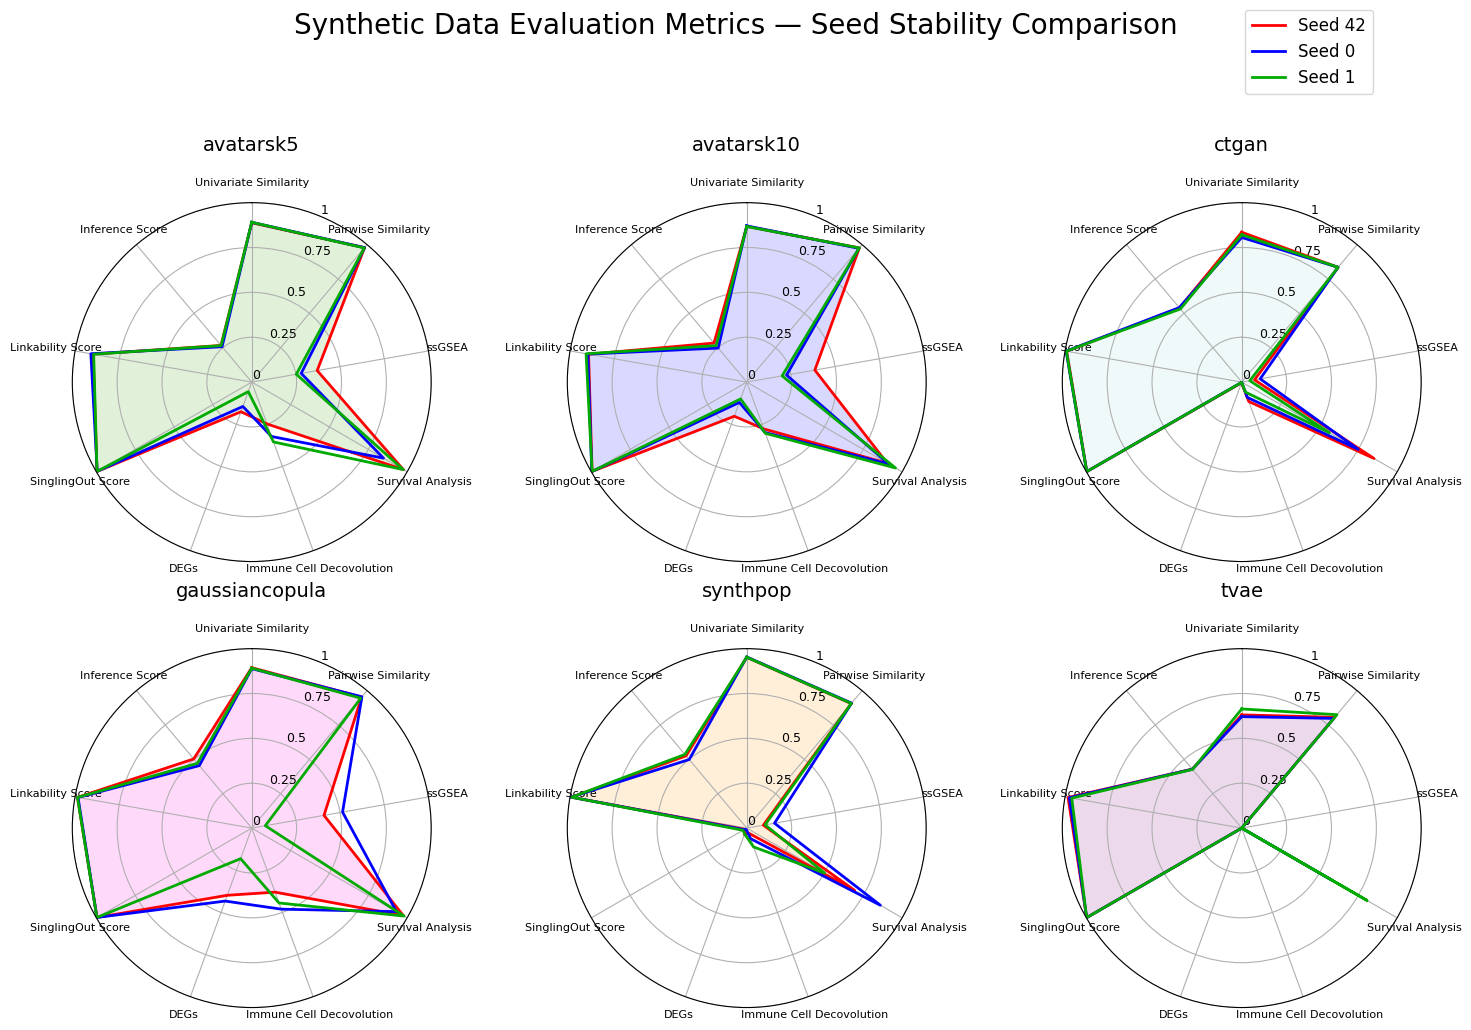

In [117]:
import matplotlib.lines as mlines

# ===========================================================
# 1. INPUT DATA
# ===========================================================

seeds = [42, 0, 1]
tools = ["avatarsk5","avatarsk10","ctgan","gaussiancopula","synthpop","tvae"]

data_seed = {}
for seed in seeds:
    data = {
        "Dataset": tools,
        "Univariate Similarity": Univariate_Similarity[seed],
        "Pairwise Similarity": Pw_Similarity[seed],
        "ssGSEA": ssGSEA_Scores[seed],
        "Survival Analysis": SA_Scores[seed],
        "Immune Cell Decovolution": ImmuneDecos_Scores[seed],
        "DEGs": DEG_Scores[seed],
        "SinglingOut Score" : SinglingOut_Scores[seed],
        "Linkability Score": Linkability_Scores[seed],
        "Inference Score": Inference_Scores[seed]
    }
    data_seed[seed] = data

# ===========================================================
# 2. PREPARE DATAFRAMES
# ===========================================================

dfs = {seed: pd.DataFrame(data_seed[seed]).fillna(0) for seed in seeds}
metrics = dfs[seeds[0]].columns[1:]

# Tạo màu cho 3 seeds
seed_colors = {
    seeds[0]: "#FF0000",   # đỏ
    seeds[1]: "#0000FF",   # xanh
    seeds[2]: "#00AA00"    # xanh lá
}

# ===========================================================
# 3. RADAR SETUP
# ===========================================================

N = len(metrics)
theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
theta = np.concatenate([theta, [theta[0]]])

r_ticks = [0, 0.25, 0.5, 0.75, 1.0]
r_labels = ["0", "0.25", "0.5", "0.75", "1"]

dataset_colors = ['#339F00', '#0500FF', '#9CDADB', '#FF00DE', '#FF9900', '#800080']

fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw={"projection": "polar"})
axes = axes.flatten()

# ===========================================================
# 4. PLOT
# ===========================================================

for ds_idx in range(len(tools)):
    ax = axes[ds_idx]
    dataset_name = dfs[seeds[0]].loc[ds_idx, "Dataset"]

    # background fill (optional)
    bg_values = dfs[seeds[0]].iloc[ds_idx][metrics].tolist()
    bg_values = bg_values + [bg_values[0]]
    ax.fill(theta, bg_values, color=dataset_colors[ds_idx], alpha=0.15)

    # Plot lines for each seed
    for seed in seeds:
        values = dfs[seed].iloc[ds_idx][metrics].tolist()
        values = values + [values[0]]

        ax.plot(theta, values,
                linewidth=2,
                linestyle="solid",
                color=seed_colors[seed])

    ax.set_title(dataset_name, size=14, pad=20)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_ylim(0, 1)
    ax.set_yticks(r_ticks)
    ax.set_yticklabels(r_labels, size=9)
    ax.set_xticks(theta[:-1])
    ax.set_xticklabels(metrics, size=8)

# ===========================================================
# 5. LEGEND CHO 3 SEEDS
# ===========================================================

fig.suptitle("Synthetic Data Evaluation Metrics — Seed Stability Comparison", fontsize=20, y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.95])

# create dynamic legend
handles = [
    mlines.Line2D([], [], color=seed_colors[seed], linewidth=2, label=f"Seed {seed}")
    for seed in seeds
]

fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.93, 1.03), fontsize=12)
fig.savefig(f"SummaryRadarPlot_SeedStability.png", dpi = 300, bbox_inches="tight")
plt.show()